# DATA 266 Lab 1 - Task 3 Live Demo & Viva Notebook
## Team 15 - Final Submitted CycleGAN

This notebook demonstrates the **final submitted Task 3 model**:

- **Member:** Anshika Goel, Viraat Chaudhary
- **Run:** `cyclegan_baseline_rtx4090_run001`
- **Final checkpoint:** `epoch_0125.pt`
- **Epoch:** 125
- **Global step:** 879,750
- **A -> B:** Monet -> Photo
- **B -> A:** Photo -> Monet

The demo verifies the frozen checkpoint, reconstructs the exact CycleGAN, shows fresh translations in both directions, displays architecture/hyperparameters/metrics, demonstrates real difficult final-model cases, and finally executes the unchanged instructor FID/MiFID evaluator and compares the fresh result with the values submitted to Kaggle.

### Important failure-analysis boundary

The old visual contact sheet under `outputs/failure_analysis/` belongs to the historical epoch-50 control. This notebook **does not relabel it as epoch 125**. Final-model difficult cases are selected from the current epoch-125 per-sample content-cosine, cycle-L1 and cycle-LPIPS artifacts, and then run live through the epoch-125 generators.

In [1]:
from __future__ import annotations
import hashlib, importlib.util, io, json, math, os, shutil, subprocess, sys, tempfile, time
from pathlib import Path
from typing import Any
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image as PILImage
from IPython.display import Image, Markdown, display

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 150)
pd.set_option('display.width', 240)

print('Python:', sys.version.split()[0])
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
print('Kernel executable:', sys.executable)

Python: 3.11.9
PyTorch: 2.13.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
Kernel executable: C:\Users\aradh\Desktop\DATA 266 Generative AI and LLM\Lab1\.venv\Scripts\python.exe


In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if ((candidate / 'task3_gan').is_dir()
                and (candidate / 'Part3_Evaluation_Script.ipynb').is_file()
                and (candidate / 'README.md').is_file()):
            return candidate
    raise FileNotFoundError('Could not locate the Lab1 repository root.')

ROOT = find_repo_root()
TASK3 = ROOT / 'task3_gan'
MEMBER = TASK3 / 'Anshika_Goel'
CODE_ROOT = MEMBER / 'code'
CONFIG_PATH = MEMBER / 'configs' / 'cyclegan_baseline.json'
CHECKPOINT_PATH = MEMBER / 'checkpoints' / 'cyclegan_baseline_rtx4090_run001' / 'epoch_0125.pt'
MONET_DIR = TASK3 / 'data' / 'monet_jpg'
PHOTO_DIR = TASK3 / 'data' / 'photo_jpg'
EVALUATOR_PATH = ROOT / 'Part3_Evaluation_Script.ipynb'
SUBMISSION_PATH = ROOT / 'submission.csv'
OFFICIAL_PREDICTION_ROOT = MEMBER / 'outputs' / 'cyclegan_baseline_rtx4090_run001' / 'official_epoch125_predictions'
COMPARISON_PREDICTION_ROOT = MEMBER / 'outputs' / 'improvement_checkpoint_comparison_epoch80_to125' / 'epoch_0125'

EXPECTED_CHECKPOINT_SHA256 = '3216b4997ed51962590251170ca5cbd6d00fb444479a8b5cd9480f0cfbeab7ec'
EXPECTED_CONFIG_SHA256 = '4795c20ee2d0307d26659da578aa6e42834cd10def8ca1bd088285c0216bfae5'
EXPECTED_EVALUATOR_SHA256 = '702a1265433bf2f15c7900c83442c626d10ac0918094d093dde8ef82069d4cef'
EXPECTED_SUBMISSION_SHA256 = 'ccedbe1b814c4fce43b43274ff9b476ecaeb395dd7da50401832bb0802be173c'
EXPECTED_FID = 97.46614849815103
EXPECTED_MIFID = 0.40686556964620363
EXPECTED_EPOCH = 125
EXPECTED_GLOBAL_STEP = 879750
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print('Repository root:', ROOT)
print('Task 3 member root:', MEMBER)
print('Demo device:', DEVICE)

Repository root: C:\Users\aradh\Desktop\DATA 266 Generative AI and LLM\Lab1
Task 3 member root: C:\Users\aradh\Desktop\DATA 266 Generative AI and LLM\Lab1\task3_gan\Anshika_Goel
Demo device: cuda:0


# A. Preflight and frozen-artifact identity

The evaluator should first see that the notebook is using the exact final checkpoint, canonical config, real local Task 3 data, final metrics, and the unchanged instructor evaluator.

In [3]:
REQUIRED = [
    CONFIG_PATH, CHECKPOINT_PATH, CODE_ROOT/'models.py', CODE_ROOT/'train.py', CODE_ROOT/'data.py',
    MONET_DIR, PHOTO_DIR, EVALUATOR_PATH, SUBMISSION_PATH,
    MEMBER/'outputs'/'metrics'/'automatic_metrics_report.csv',
    MEMBER/'outputs'/'metrics'/'directional_fid_mifid.json',
    MEMBER/'outputs'/'metrics'/'generative_precision_recall.json',
    MEMBER/'outputs'/'metrics'/'content_preservation_cosine_per_sample.csv',
    MEMBER/'outputs'/'metrics'/'cycle_reconstruction_l1_per_sample.csv',
    MEMBER/'outputs'/'metrics'/'cycle_reconstruction_lpips_per_sample.csv',
    MEMBER/'outputs'/'improvement_checkpoint_comparison_epoch80_to125'/'checkpoint_comparison_summary.csv',
    MEMBER/'failure_analysis.md',
    MEMBER/'outputs'/'evaluation'/'final_epoch125_submission_manifest.json',
    MEMBER/'outputs'/'evaluation'/'kaggle_epoch125_result.json',
]
rows=[]
for p in REQUIRED:
    rows.append({'Artifact':str(p.relative_to(ROOT)), 'Exists':p.exists(),
                 'Type':'directory' if p.is_dir() else 'file',
                 'Size (MiB)':round(p.stat().st_size/(1024**2),3) if p.is_file() else None})
preflight=pd.DataFrame(rows)
display(preflight)
missing=preflight.loc[~preflight['Exists']]
if not missing.empty:
    raise FileNotFoundError('Missing Task 3 artifacts:\n'+missing['Artifact'].to_string(index=False))
print('TASK 3 ARTIFACT PREFLIGHT: PASSED')

,Artifact,Exists,Type,Size (MiB)
0,task3_gan\Anshika_Goel\configs\cyclegan_baseline.json,True,file,0.003
1,task3_gan\Anshika_Goel\checkpoints\cyclegan_baseline_rtx4090_run001\epoch_0125.pt,True,file,398.899
2,task3_gan\Anshika_Goel\code\models.py,True,file,0.011
3,task3_gan\Anshika_Goel\code\train.py,True,file,0.042
4,task3_gan\Anshika_Goel\code\data.py,True,file,0.009
5,task3_gan\data\monet_jpg,True,directory,NaN
6,task3_gan\data\photo_jpg,True,directory,NaN
7,Part3_Evaluation_Script.ipynb,True,file,0.008
8,submission.csv,True,file,0.000
9,task3_gan\Anshika_Goel\outputs\metrics\automatic_metrics_report.csv,True,file,0.005


TASK 3 ARTIFACT PREFLIGHT: PASSED


In [4]:
def sha256_file(path: Path, chunk_size: int = 8*1024*1024) -> str:
    h=hashlib.sha256()
    with path.open('rb') as f:
        for block in iter(lambda:f.read(chunk_size), b''):
            h.update(block)
    return h.hexdigest()

def load_json(path: Path):
    return json.loads(path.read_text(encoding='utf-8'))

def flatten_dict(obj, prefix=''):
    out={}
    for k,v in obj.items():
        key=f'{prefix}.{k}' if prefix else str(k)
        if isinstance(v,dict): out.update(flatten_dict(v,key))
        else: out[key]=v
    return out

actual_checkpoint_sha=sha256_file(CHECKPOINT_PATH)
actual_config_sha=sha256_file(CONFIG_PATH)
actual_evaluator_sha=sha256_file(EVALUATOR_PATH)

identity=pd.DataFrame([
    {'Artifact':'epoch_0125.pt','Actual SHA256':actual_checkpoint_sha,'Expected SHA256':EXPECTED_CHECKPOINT_SHA256,'Exact required':True},
    {'Artifact':'cyclegan_baseline.json','Actual SHA256':actual_config_sha,'Expected SHA256':EXPECTED_CONFIG_SHA256,'Exact required':False},
    {'Artifact':'Part3_Evaluation_Script.ipynb','Actual SHA256':actual_evaluator_sha,'Expected SHA256':EXPECTED_EVALUATOR_SHA256,'Exact required':True},
])
identity['Byte-identical']=identity['Actual SHA256']==identity['Expected SHA256']
display(identity)

if actual_checkpoint_sha!=EXPECTED_CHECKPOINT_SHA256:
    raise RuntimeError('Final epoch-125 checkpoint SHA256 mismatch.')
if actual_evaluator_sha!=EXPECTED_EVALUATOR_SHA256:
    raise RuntimeError('Instructor evaluator SHA256 mismatch.')

# If repository text formatting changed, do not hide it. Verify all behavior-defining
# model/training/preprocessing fields used by this demo instead.
config_for_provenance=load_json(CONFIG_PATH)
flat_for_provenance=flatten_dict(config_for_provenance)
expected_semantics={
    'model.generator.architecture':'resnet_9block',
    'model.generator.residual_blocks':9,
    'model.generator.base_channels':64,
    'model.generator.input_channels':3,
    'model.generator.output_channels':3,
    'model.generator.normalization':'instance_norm',
    'model.generator.output_activation':'tanh',
    'model.discriminator.architecture':'patchgan_70x70',
    'model.discriminator.base_channels':64,
    'model.discriminator.layers':3,
    'model.discriminator.input_channels':3,
    'model.discriminator.normalization':'instance_norm',
    'training.batch_size':1,
    'training.learning_rate':0.0002,
    'training.beta1':0.5,
    'training.beta2':0.999,
    'training.weight_decay':0.0,
    'training.epochs':200,
    'training.constant_lr_epochs':100,
    'training.linear_decay_epochs':100,
    'training.image_pool_size':50,
    'training.mixed_precision':False,
    'training.optimizer':'adam',
    'preprocessing.train_resize':286,
    'preprocessing.train_crop':256,
    'preprocessing.horizontal_flip_probability':0.5,
    'preprocessing.evaluation_size':256,
}
semantic_rows=[]
for key,expected in expected_semantics.items():
    actual=flat_for_provenance.get(key,'<MISSING>')
    semantic_rows.append({'Field':key,'Current value':actual,'Recorded value':expected,'Matches':actual==expected})
semantic_check=pd.DataFrame(semantic_rows)
display(Markdown('### Behavior-defining configuration verification'))
display(semantic_check)
if not semantic_check['Matches'].all():
    raise RuntimeError('A behavior-defining Task 3 configuration field differs from the recorded setup.')
if actual_config_sha!=EXPECTED_CONFIG_SHA256:
    print('NOTE: current config bytes differ from the historical training-config SHA. The difference is disclosed; behavior-defining fields match, and the checkpoint itself records the expected canonical config SHA.')
print('FINAL CHECKPOINT: EXACT SHA MATCH')
print('CONFIGURATION: BEHAVIOR-DEFINING FIELDS MATCH')
print('INSTRUCTOR EVALUATOR: EXACT SHA MATCH')
print('TASK 3 FROZEN-ARTIFACT PROVENANCE: PASSED')

,Artifact,Actual SHA256,Expected SHA256,Exact required,Byte-identical
0,epoch_0125.pt,3216b4997ed51962590251170ca5cbd6d00fb444479a8b5cd9480f0cfbeab7ec,3216b4997ed51962590251170ca5cbd6d00fb444479a8b5cd9480f0cfbeab7ec,True,True
1,cyclegan_baseline.json,4795c20ee2d0307d26659da578aa6e42834cd10def8ca1bd088285c0216bfae5,4795c20ee2d0307d26659da578aa6e42834cd10def8ca1bd088285c0216bfae5,False,True
2,Part3_Evaluation_Script.ipynb,702a1265433bf2f15c7900c83442c626d10ac0918094d093dde8ef82069d4cef,702a1265433bf2f15c7900c83442c626d10ac0918094d093dde8ef82069d4cef,True,True


### Behavior-defining configuration verification

,Field,Current value,Recorded value,Matches
0,model.generator.architecture,resnet_9block,resnet_9block,True
1,model.generator.residual_blocks,9,9,True
2,model.generator.base_channels,64,64,True
3,model.generator.input_channels,3,3,True
4,model.generator.output_channels,3,3,True
5,model.generator.normalization,instance_norm,instance_norm,True
6,model.generator.output_activation,tanh,tanh,True
7,model.discriminator.architecture,patchgan_70x70,patchgan_70x70,True
8,model.discriminator.base_channels,64,64,True
9,model.discriminator.layers,3,3,True


FINAL CHECKPOINT: EXACT SHA MATCH
CONFIGURATION: BEHAVIOR-DEFINING FIELDS MATCH
INSTRUCTOR EVALUATOR: EXACT SHA MATCH
TASK 3 FROZEN-ARTIFACT PROVENANCE: PASSED


# B. Load the final epoch-125 CycleGAN

The checkpoint stores four network state dictionaries:

- `generator_a_to_b`: Monet -> Photo
- `generator_b_to_a`: Photo -> Monet
- `discriminator_a`: Monet-domain PatchGAN
- `discriminator_b`: Photo-domain PatchGAN

All four networks are reconstructed from the committed production code and loaded with `strict=True`.

In [5]:
config=load_json(CONFIG_PATH)
if str(CODE_ROOT) not in sys.path: sys.path.insert(0,str(CODE_ROOT))
spec=importlib.util.spec_from_file_location('task3_demo_train_module', CODE_ROOT/'train.py')
if spec is None or spec.loader is None: raise ImportError('Unable to import train.py')
train_module=importlib.util.module_from_spec(spec)
sys.modules['task3_demo_train_module']=train_module
spec.loader.exec_module(train_module)
from data import build_eval_transform, discover_images
from models import count_trainable_parameters

networks=train_module.build_networks(config=config, device=DEVICE)
checkpoint=torch.load(CHECKPOINT_PATH,map_location='cpu',weights_only=False)
print('Checkpoint epoch:',checkpoint['epoch_completed'])
print('Checkpoint global step:',checkpoint['global_step'])
print('Checkpoint config SHA:',checkpoint['config_sha256'])
if int(checkpoint['epoch_completed'])!=EXPECTED_EPOCH: raise RuntimeError('Epoch mismatch')
if int(checkpoint['global_step'])!=EXPECTED_GLOBAL_STEP: raise RuntimeError('Global-step mismatch')
if str(checkpoint['config_sha256'])!=EXPECTED_CONFIG_SHA256: raise RuntimeError('Config SHA mismatch')
expected={'generator_a_to_b','generator_b_to_a','discriminator_a','discriminator_b'}
if set(checkpoint['network_state_dicts'])!=expected: raise RuntimeError('Network-state keys mismatch')

load_rows=[]
for name,net in networks.items():
    result=net.load_state_dict(checkpoint['network_state_dicts'][name],strict=True)
    net.eval()
    finite=all(torch.isfinite(p).all().item() for p in net.parameters())
    load_rows.append({'Network':name,'Trainable parameters':count_trainable_parameters(net),
                      'Missing keys':len(result.missing_keys),'Unexpected keys':len(result.unexpected_keys),
                      'All parameters finite':finite})
load_table=pd.DataFrame(load_rows)
display(load_table)
if (load_table['Missing keys']!=0).any() or (load_table['Unexpected keys']!=0).any() or (~load_table['All parameters finite']).any():
    raise RuntimeError('Strict checkpoint load failed')

generator_a_to_b=networks['generator_a_to_b']
generator_b_to_a=networks['generator_b_to_a']
discriminator_a=networks['discriminator_a']
discriminator_b=networks['discriminator_b']
total_parameters=int(load_table['Trainable parameters'].sum())
print('Total four-network trainable parameters:',f'{total_parameters:,}')
if total_parameters!=28285832: raise RuntimeError('Parameter count mismatch')
print('FINAL EPOCH-125 CYCLEGAN CHECKPOINT LOAD: PASSED')

Checkpoint epoch: 125
Checkpoint global step: 879750
Checkpoint config SHA: 4795c20ee2d0307d26659da578aa6e42834cd10def8ca1bd088285c0216bfae5


,Network,Trainable parameters,Missing keys,Unexpected keys,All parameters finite
0,generator_a_to_b,11378179,0,0,True
1,generator_b_to_a,11378179,0,0,True
2,discriminator_a,2764737,0,0,True
3,discriminator_b,2764737,0,0,True


Total four-network trainable parameters: 28,285,832
FINAL EPOCH-125 CYCLEGAN CHECKPOINT LOAD: PASSED


In [6]:
display(Markdown('## B1. Architecture summary'))
gcfg=config['model']['generator']; dcfg=config['model']['discriminator']
residual_count=sum(1 for m in generator_a_to_b.modules() if m.__class__.__name__=='ResidualBlock')
with torch.inference_mode():
    x=torch.zeros(1,3,256,256,device=DEVICE)
    y=generator_a_to_b(x)
    patch=discriminator_b(y)
architecture_table=pd.DataFrame([
    {'Property':'Generators','Final model':'2 x ResNet generators'},
    {'Property':'Residual blocks per generator','Final model':residual_count},
    {'Property':'Generator base channels','Final model':gcfg['base_channels']},
    {'Property':'Generator normalization','Final model':gcfg['normalization']},
    {'Property':'Generator output activation','Final model':gcfg['output_activation']},
    {'Property':'Generator 256x256 I/O','Final model':f'{tuple(x.shape)} -> {tuple(y.shape)}'},
    {'Property':'Discriminators','Final model':'2 x 70x70 PatchGAN'},
    {'Property':'Discriminator layers','Final model':dcfg['layers']},
    {'Property':'Patch output for 256x256','Final model':str(tuple(patch.shape))},
    {'Property':'A->B generator parameters','Final model':count_trainable_parameters(generator_a_to_b)},
    {'Property':'B->A generator parameters','Final model':count_trainable_parameters(generator_b_to_a)},
    {'Property':'Each discriminator parameters','Final model':count_trainable_parameters(discriminator_a)},
    {'Property':'Total parameters','Final model':total_parameters},
])
display(architecture_table)

## B1. Architecture summary

,Property,Final model
0,Generators,2 x ResNet generators
1,Residual blocks per generator,9
2,Generator base channels,64
3,Generator normalization,instance_norm
4,Generator output activation,tanh
5,Generator 256x256 I/O,"(1, 3, 256, 256) -> (1, 3, 256, 256)"
6,Discriminators,2 x 70x70 PatchGAN
7,Discriminator layers,3
8,Patch output for 256x256,"(1, 1, 30, 30)"
9,A->B generator parameters,11378179


In [7]:
display(Markdown('## B2. Complete architecture / loss / training / preprocessing config'))
flat=flatten_dict(config)
config_table=pd.DataFrame([{'Configuration field':k,'Value':v} for k,v in flat.items()
                           if k.startswith(('model.','training.','loss.','preprocessing.','dataloader.'))])
display(config_table)

## B2. Complete architecture / loss / training / preprocessing config

,Configuration field,Value
0,dataloader.drop_last,False
1,dataloader.num_workers,4
2,dataloader.persistent_workers,True
3,dataloader.pin_memory,True
4,dataloader.shuffle,True
5,loss.adversarial,least_squares_gan_mse
6,loss.cycle,l1
7,loss.effective_identity_weight_a,5.0
8,loss.effective_identity_weight_b,5.0
9,loss.identity,l1


In [8]:
display(Markdown('## B3. Hyperparameters'))
t=config['training']; p=config['preprocessing']; l=config['loss']
def pick(mapping,*keys,default=None):
    for k in keys:
        if k in mapping: return mapping[k]
    return default
hyperparameters=pd.DataFrame([
 {'Hyperparameter':'Selected final checkpoint','Value':'epoch 125 / global step 879,750'},
 {'Hyperparameter':'Configured max epochs','Value':t['epochs']},
 {'Hyperparameter':'Constant LR epochs','Value':t['constant_lr_epochs']},
 {'Hyperparameter':'Linear decay epochs','Value':t['linear_decay_epochs']},
 {'Hyperparameter':'Initial learning rate','Value':t['learning_rate']},
 {'Hyperparameter':'LR at selected epoch','Value':0.00015},
 {'Hyperparameter':'Optimizer','Value':t['optimizer']},
 {'Hyperparameter':'Adam beta1','Value':t['beta1']},
 {'Hyperparameter':'Adam beta2','Value':t['beta2']},
 {'Hyperparameter':'Weight decay','Value':t['weight_decay']},
 {'Hyperparameter':'Batch size','Value':t['batch_size']},
 {'Hyperparameter':'Mixed precision','Value':t['mixed_precision']},
 {'Hyperparameter':'Replay pool size','Value':t['image_pool_size']},
 {'Hyperparameter':'Cycle loss weights','Value':'10 / 10'},
 {'Hyperparameter':'Identity ratio / effective weights','Value':'0.5 / 5 per direction'},
 {'Hyperparameter':'Train resize','Value':p['train_resize']},
 {'Hyperparameter':'Random crop','Value':p['train_crop']},
 {'Hyperparameter':'Horizontal flip probability','Value':p['horizontal_flip_probability']},
 {'Hyperparameter':'Evaluation image size','Value':p['evaluation_size']},
 {'Hyperparameter':'Normalization','Value':'mean=0.5, std=0.5 -> [-1,1]'},
 {'Hyperparameter':'Training precision','Value':'FP32'},
 {'Hyperparameter':'Production training GPU','Value':'NVIDIA GeForce RTX 4090'},
])
display(hyperparameters)

## B3. Hyperparameters

,Hyperparameter,Value
0,Selected final checkpoint,"epoch 125 / global step 879,750"
1,Configured max epochs,200
2,Constant LR epochs,100
3,Linear decay epochs,100
4,Initial learning rate,0.0002
5,LR at selected epoch,0.00015
6,Optimizer,adam
7,Adam beta1,0.5
8,Adam beta2,0.999
9,Weight decay,0.0


# C. Fresh live examples in both directions

These cells use the real local Task 3 source images and the loaded epoch-125 generators. Evaluation preprocessing is deterministic at 256x256 and normalized to `[-1,1]`.

In [9]:
monet_paths=discover_images(MONET_DIR); photo_paths=discover_images(PHOTO_DIR)
print('Monet images:',len(monet_paths)); print('Photo images:',len(photo_paths))
if len(monet_paths)!=300: raise RuntimeError(f'Expected 300 Monet images, found {len(monet_paths)}')
if len(photo_paths)!=7038: raise RuntimeError(f'Expected 7038 photos, found {len(photo_paths)}')
eval_transform=build_eval_transform(image_size=int(config['preprocessing']['evaluation_size']))
print('REAL TASK 3 DATASET COUNTS: PASSED')

Monet images: 300
Photo images: 7038
REAL TASK 3 DATASET COUNTS: PASSED


In [10]:
def tensor_to_image(t):
    t=t.detach().float().cpu().clamp(-1,1)
    return np.clip(((t+1)/2).permute(1,2,0).numpy(),0,1)

def load_source_tensor(path):
    with PILImage.open(path) as im:
        return eval_transform(im.convert('RGB'))

@torch.inference_mode()
def translate(path,generator):
    src=load_source_tensor(path)
    out=generator(src.unsqueeze(0).to(DEVICE))[0].cpu()
    return src.cpu(),out

@torch.inference_mode()
def translate_cycle(path,direct,reverse):
    src=load_source_tensor(path); x=src.unsqueeze(0).to(DEVICE)
    y=direct(x); cyc=reverse(y)
    return src.cpu(),y[0].cpu(),cyc[0].cpu()

def show_pair(src,out,t1,t2,name):
    fig,ax=plt.subplots(1,2,figsize=(11,5))
    ax[0].imshow(tensor_to_image(src)); ax[0].set_title(t1); ax[0].axis('off')
    ax[1].imshow(tensor_to_image(out)); ax[1].set_title(t2); ax[1].axis('off')
    fig.suptitle(name); plt.tight_layout(); plt.show()

def show_triplet(src,out,cyc,titles,name):
    fig,ax=plt.subplots(1,3,figsize=(15,5))
    for a,t,title in zip(ax,(src,out,cyc),titles):
        a.imshow(tensor_to_image(t)); a.set_title(title); a.axis('off')
    fig.suptitle(name); plt.tight_layout(); plt.show()

## C1. Fresh Monet -> Photo examples

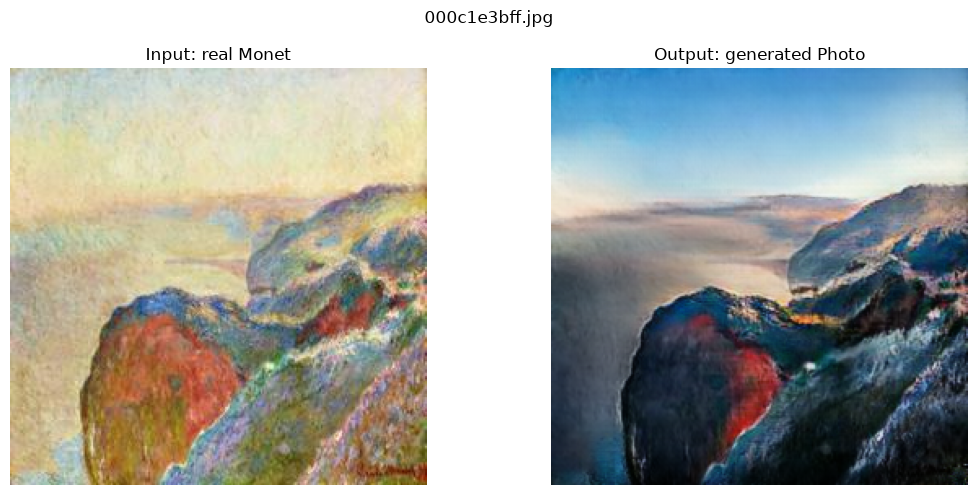

000c1e3bff.jpg | live Monet->Photo inference: 0.039 s


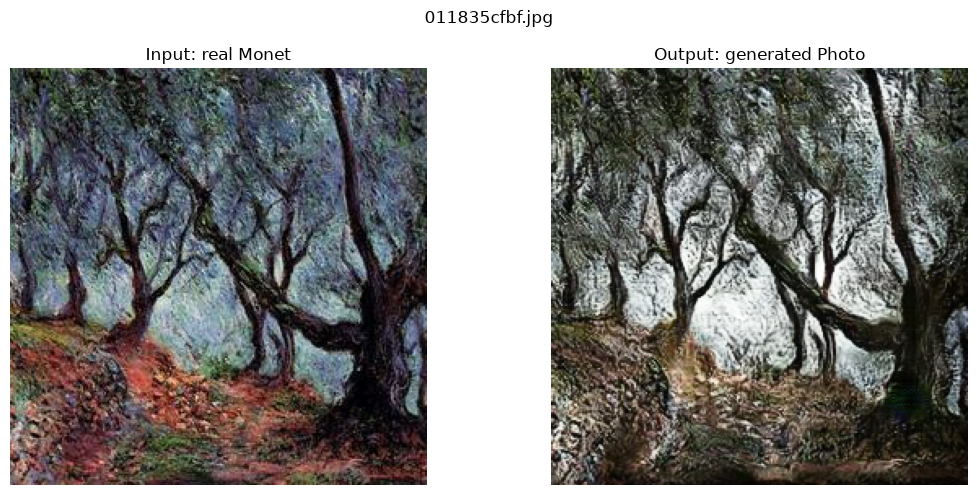

011835cfbf.jpg | live Monet->Photo inference: 0.039 s


In [11]:
display(Markdown('## C1. Fresh Monet -> Photo examples'))
for path in monet_paths[:2]:
    start=time.perf_counter(); src,out=translate(path,generator_a_to_b); elapsed=time.perf_counter()-start
    show_pair(src,out,'Input: real Monet','Output: generated Photo',path.name)
    print(f'{path.name} | live Monet->Photo inference: {elapsed:.3f} s')

## C2. Fresh Photo -> Monet examples

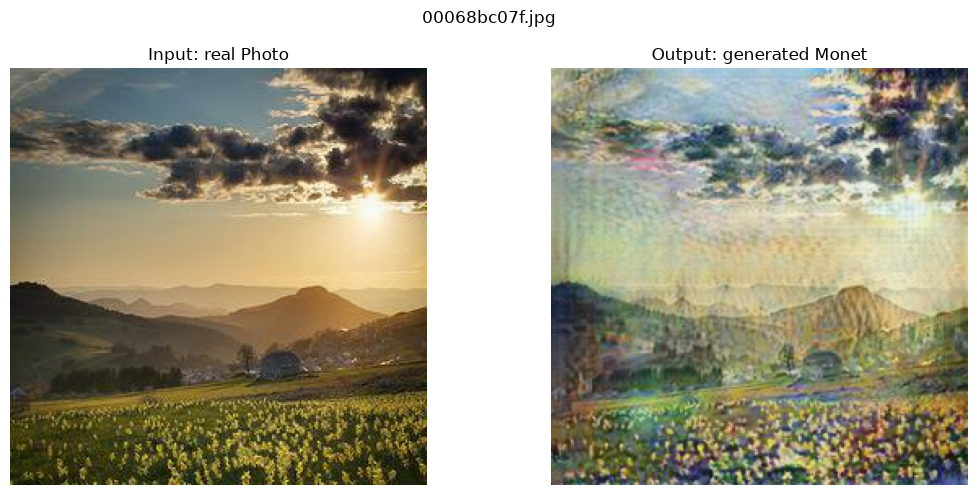

00068bc07f.jpg | live Photo->Monet inference: 0.025 s


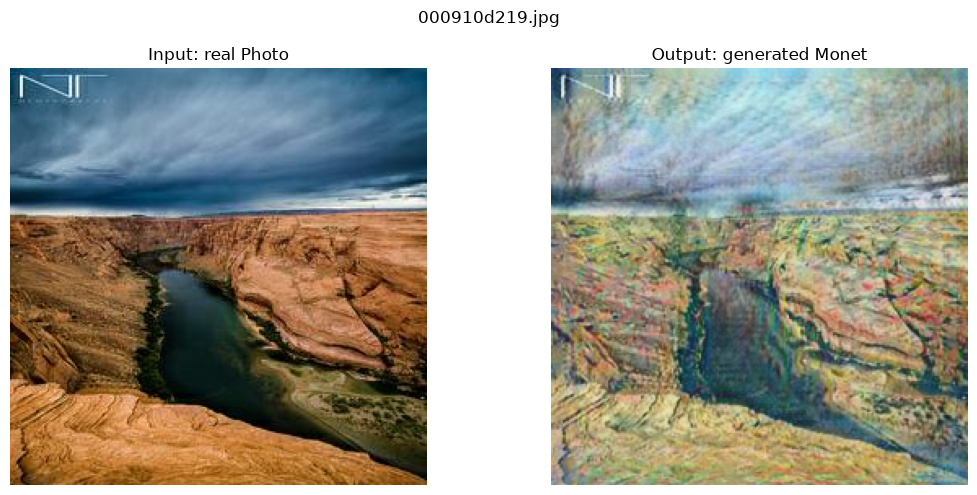

000910d219.jpg | live Photo->Monet inference: 0.028 s


In [12]:
display(Markdown('## C2. Fresh Photo -> Monet examples'))
for path in photo_paths[:2]:
    start=time.perf_counter(); src,out=translate(path,generator_b_to_a); elapsed=time.perf_counter()-start
    show_pair(src,out,'Input: real Photo','Output: generated Monet',path.name)
    print(f'{path.name} | live Photo->Monet inference: {elapsed:.3f} s')

# D. Final epoch-125 metrics

The official competition outputs are the two-direction-average **FID and MiFID** from the unchanged instructor evaluator. The notebook also shows KID, precision/recall, content cosine, cycle L1 and the complete recorded metrics table because these measure different properties of the generator.

In [13]:
directional=load_json(MEMBER/'outputs'/'metrics'/'directional_fid_mifid.json')
pr=load_json(MEMBER/'outputs'/'metrics'/'generative_precision_recall.json')
cycle_l1=load_json(MEMBER/'outputs'/'metrics'/'cycle_reconstruction_l1.json')
comparison=pd.read_csv(MEMBER/'outputs'/'improvement_checkpoint_comparison_epoch80_to125'/'checkpoint_comparison_summary.csv')
row125=comparison.loc[comparison['epoch']==125]
if len(row125)!=1: raise RuntimeError('Expected one epoch-125 comparison row')
r=row125.iloc[0]
compact=pd.DataFrame([
 {'Metric':'FID','Monet -> Photo':directional['A2B_monet_to_photo']['fid'],'Photo -> Monet':directional['B2A_photo_to_monet']['fid'],'Two-direction average':directional['two_direction_average']['official_instructor_fid']},
 {'Metric':'MiFID','Monet -> Photo':directional['A2B_monet_to_photo']['mifid'],'Photo -> Monet':directional['B2A_photo_to_monet']['mifid'],'Two-direction average':directional['two_direction_average']['official_instructor_mifid']},
 {'Metric':'KID','Monet -> Photo':r['kid_a2b'],'Photo -> Monet':r['kid_b2a'],'Two-direction average':r['kid_average']},
 {'Metric':'Generative precision','Monet -> Photo':pr['A2B_monet_to_photo']['precision'],'Photo -> Monet':pr['B2A_photo_to_monet']['precision'],'Two-direction average':pr['two_direction_average']['precision']},
 {'Metric':'Generative recall','Monet -> Photo':pr['A2B_monet_to_photo']['recall'],'Photo -> Monet':pr['B2A_photo_to_monet']['recall'],'Two-direction average':pr['two_direction_average']['recall']},
 {'Metric':'Cycle L1 [0,1]','Monet -> Photo':cycle_l1['A2B2A_monet_to_photo_to_monet']['mean'],'Photo -> Monet':cycle_l1['B2A2B_photo_to_monet_to_photo']['mean'],'Two-direction average':cycle_l1['two_direction_mean']},
 {'Metric':'Content cosine','Monet -> Photo':r['content_cosine_a2b'],'Photo -> Monet':r['content_cosine_b2a'],'Two-direction average':r['content_cosine_average']},
])
display(compact)

,Metric,Monet -> Photo,Photo -> Monet,Two-direction average
0,FID,96.068450,98.864013,97.466148
1,MiFID,0.413548,0.400183,0.406866
2,KID,0.017190,0.007900,0.012545
3,Generative precision,0.780000,0.433333,0.606667
4,Generative recall,0.333333,0.630000,0.481667
5,"Cycle L1 [0,1]",0.032256,0.034622,0.033439
6,Content cosine,0.783451,0.754759,0.769105


In [14]:
display(Markdown('## D1. Complete machine-readable final metrics'))
automatic_metrics=pd.read_csv(MEMBER/'outputs'/'metrics'/'automatic_metrics_report.csv')
display(automatic_metrics)

## D1. Complete machine-readable final metrics

,category,metric,direction,value,std,unit,source_artifact,note
0,distribution_quality,FID,A2B_monet_to_photo,9.606845e+01,NaN,NaN,directional_fid_mifid.json,NaN
1,distribution_quality,FID,B2A_photo_to_monet,9.886401e+01,NaN,NaN,directional_fid_mifid.json,NaN
2,distribution_quality,FID,official_two_direction_average,9.746615e+01,NaN,NaN,../../../../submission.csv,Unchanged instructor evaluation notebook.
3,distribution_quality,MiFID,A2B_monet_to_photo,4.135484e-01,NaN,NaN,directional_fid_mifid.json,NaN
4,distribution_quality,MiFID,B2A_photo_to_monet,4.001827e-01,NaN,NaN,directional_fid_mifid.json,NaN
5,distribution_quality,MiFID,official_two_direction_average,4.068656e-01,NaN,NaN,../../../../submission.csv,Unchanged instructor evaluation notebook.
6,distribution_quality,KID,A2B_monet_to_photo,1.718976e-02,NaN,NaN,kid_metrics.json,50 deterministic subsets of 100.
7,distribution_quality,KID,B2A_photo_to_monet,7.900305e-03,NaN,NaN,kid_metrics.json,50 deterministic subsets of 100.
8,distribution_quality,KID,two_direction_average,1.254503e-02,NaN,NaN,kid_metrics.json,50 deterministic subsets of 100.
9,distribution_quality,Generative precision,A2B_monet_to_photo,7.800000e-01,NaN,NaN,generative_precision_recall.json,NaN


## D2. Saved training / optimization curves

### Generator Losses By Epoch

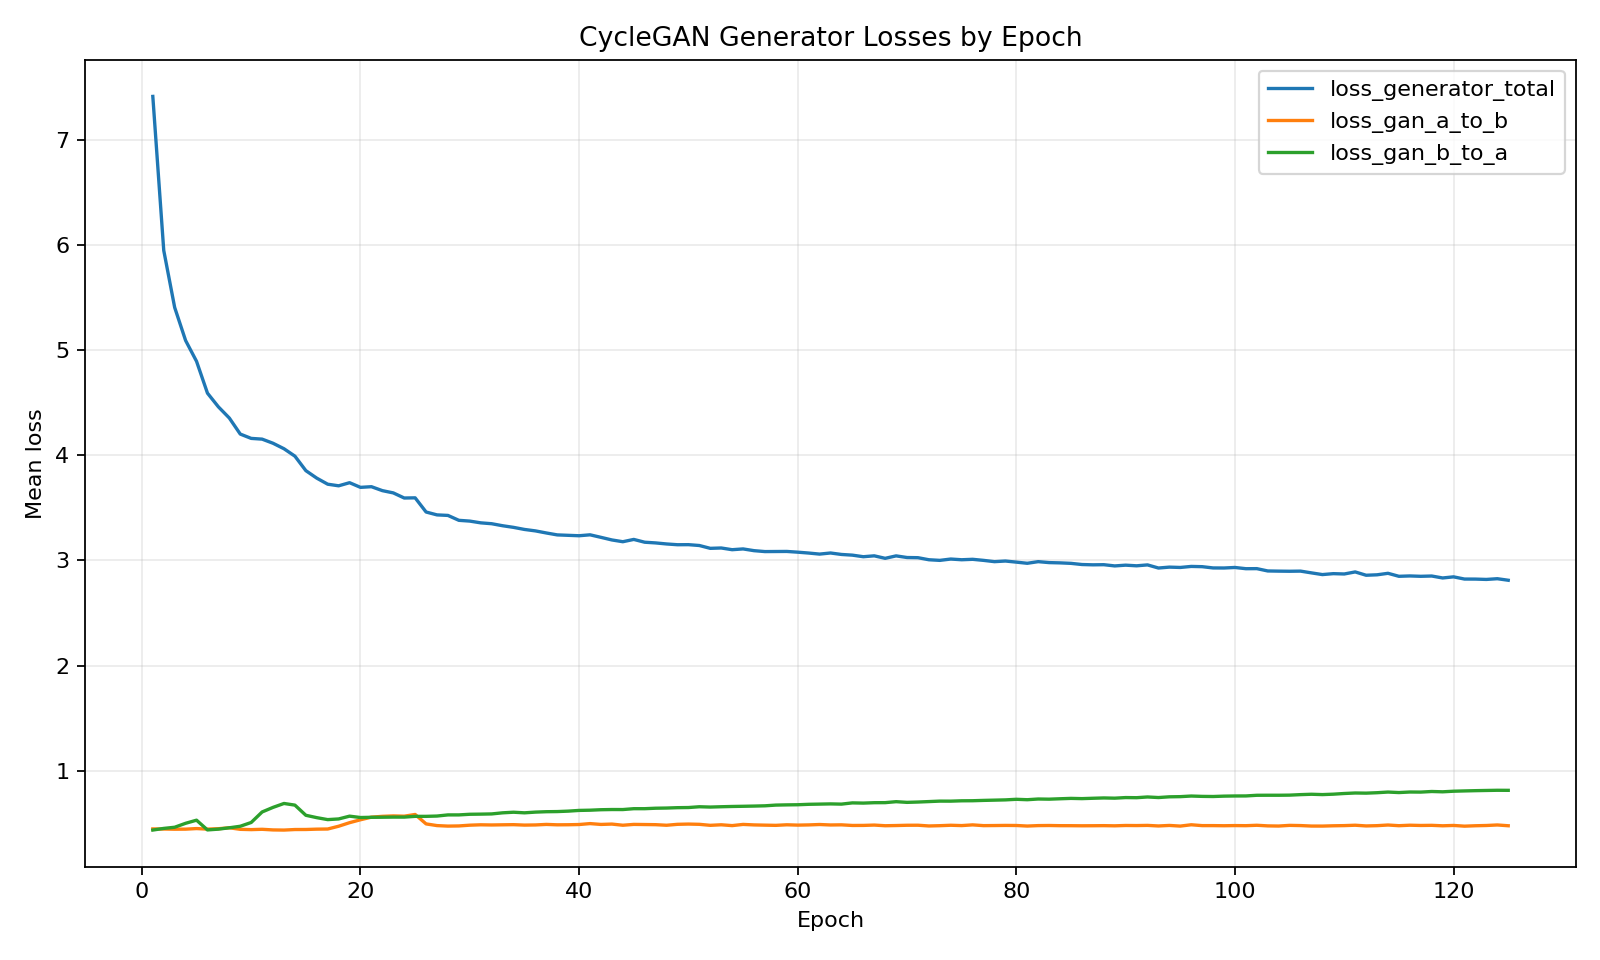

### Discriminator Losses By Epoch

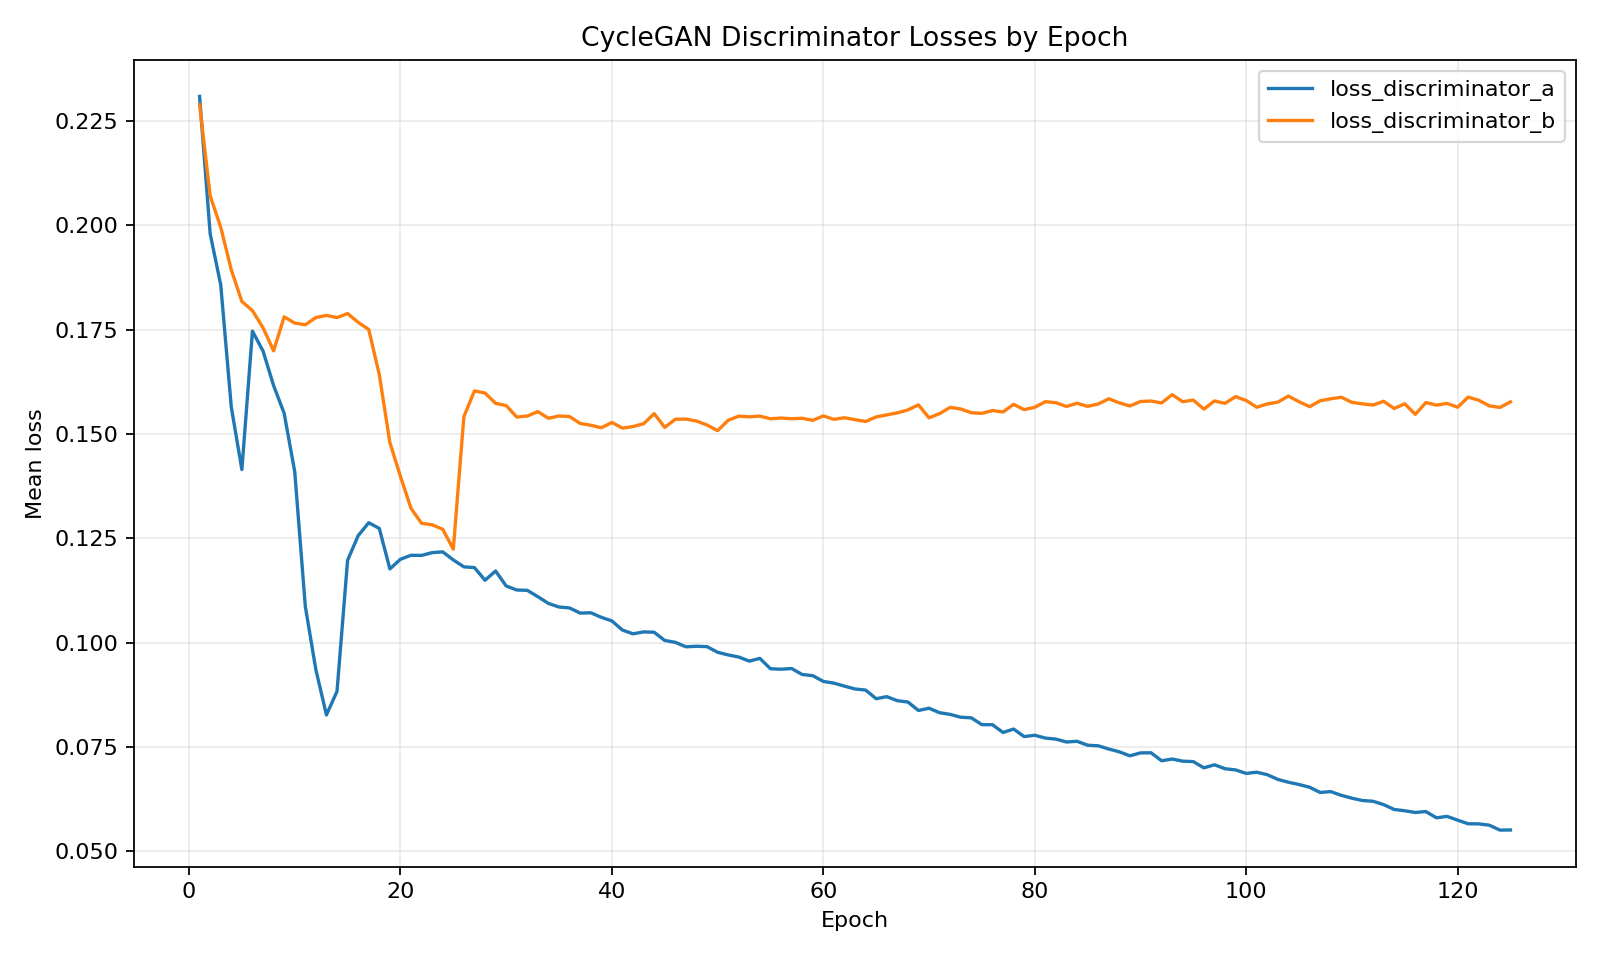

### Cycle Consistency Losses By Epoch

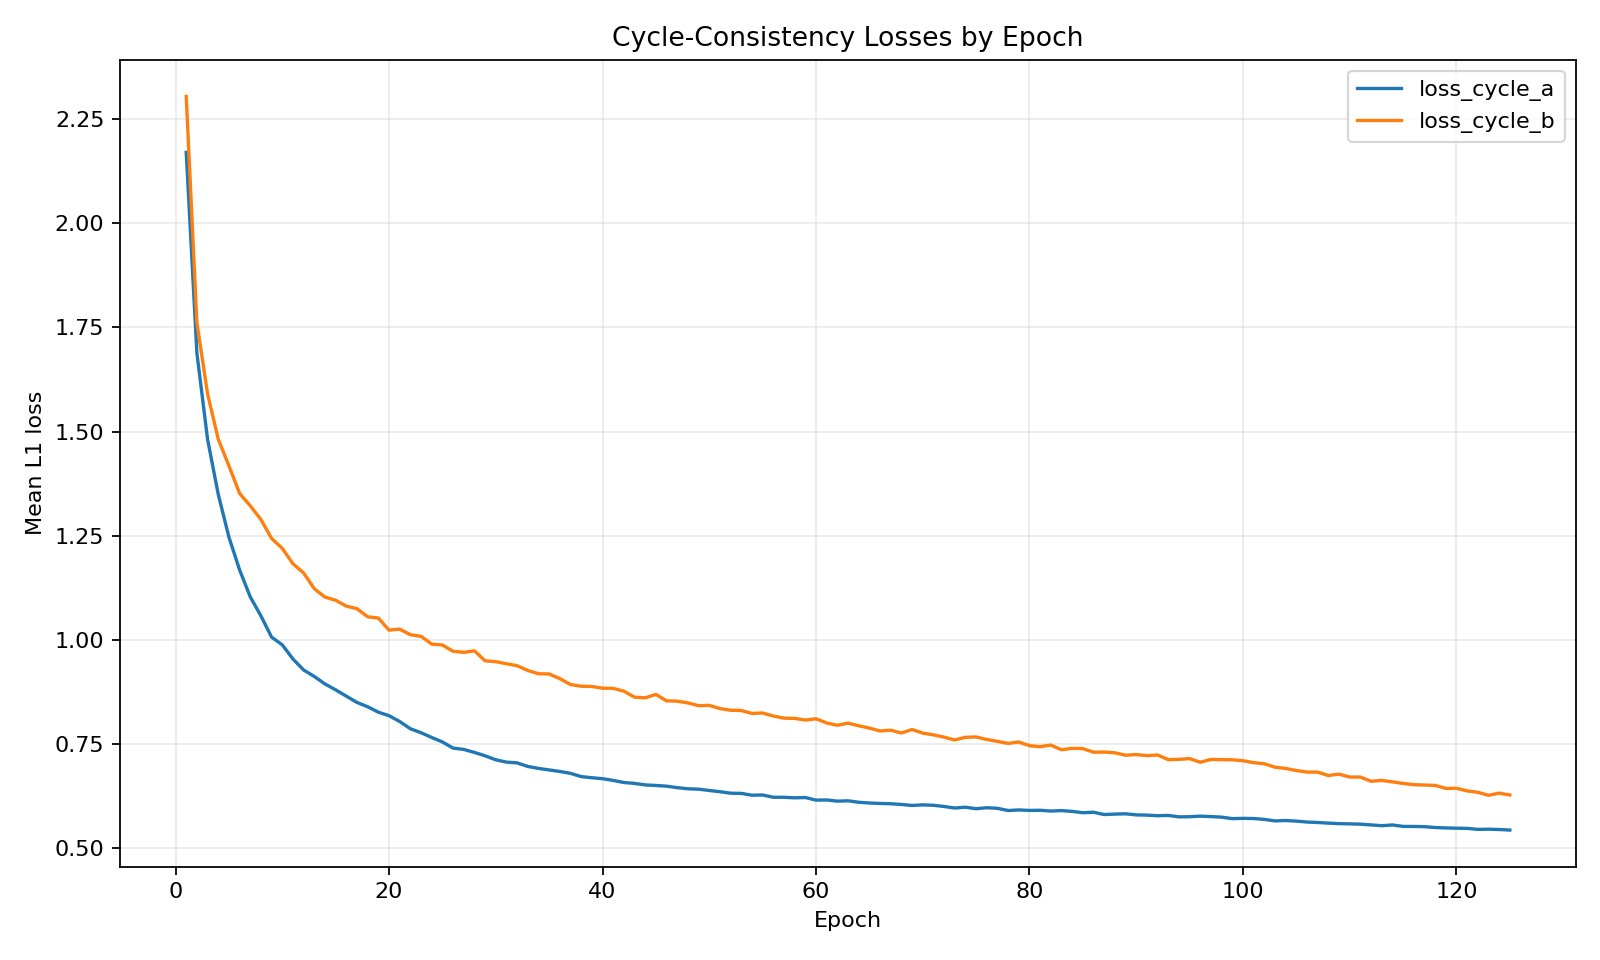

### Identity Losses By Epoch

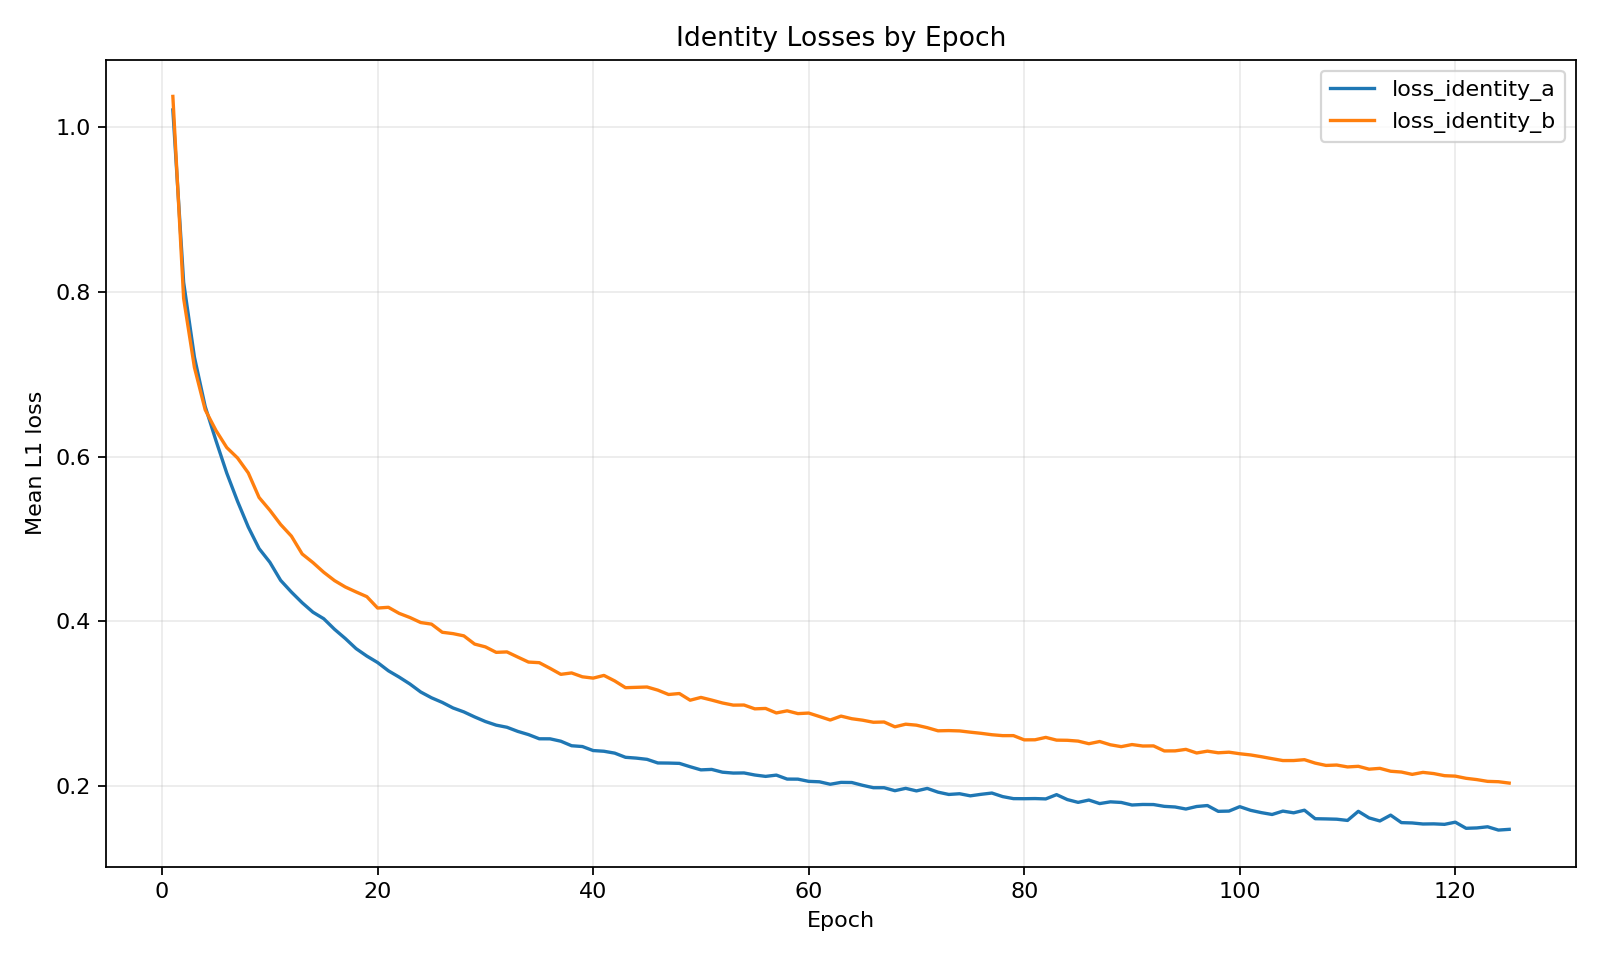

### Gradient Norms By Epoch

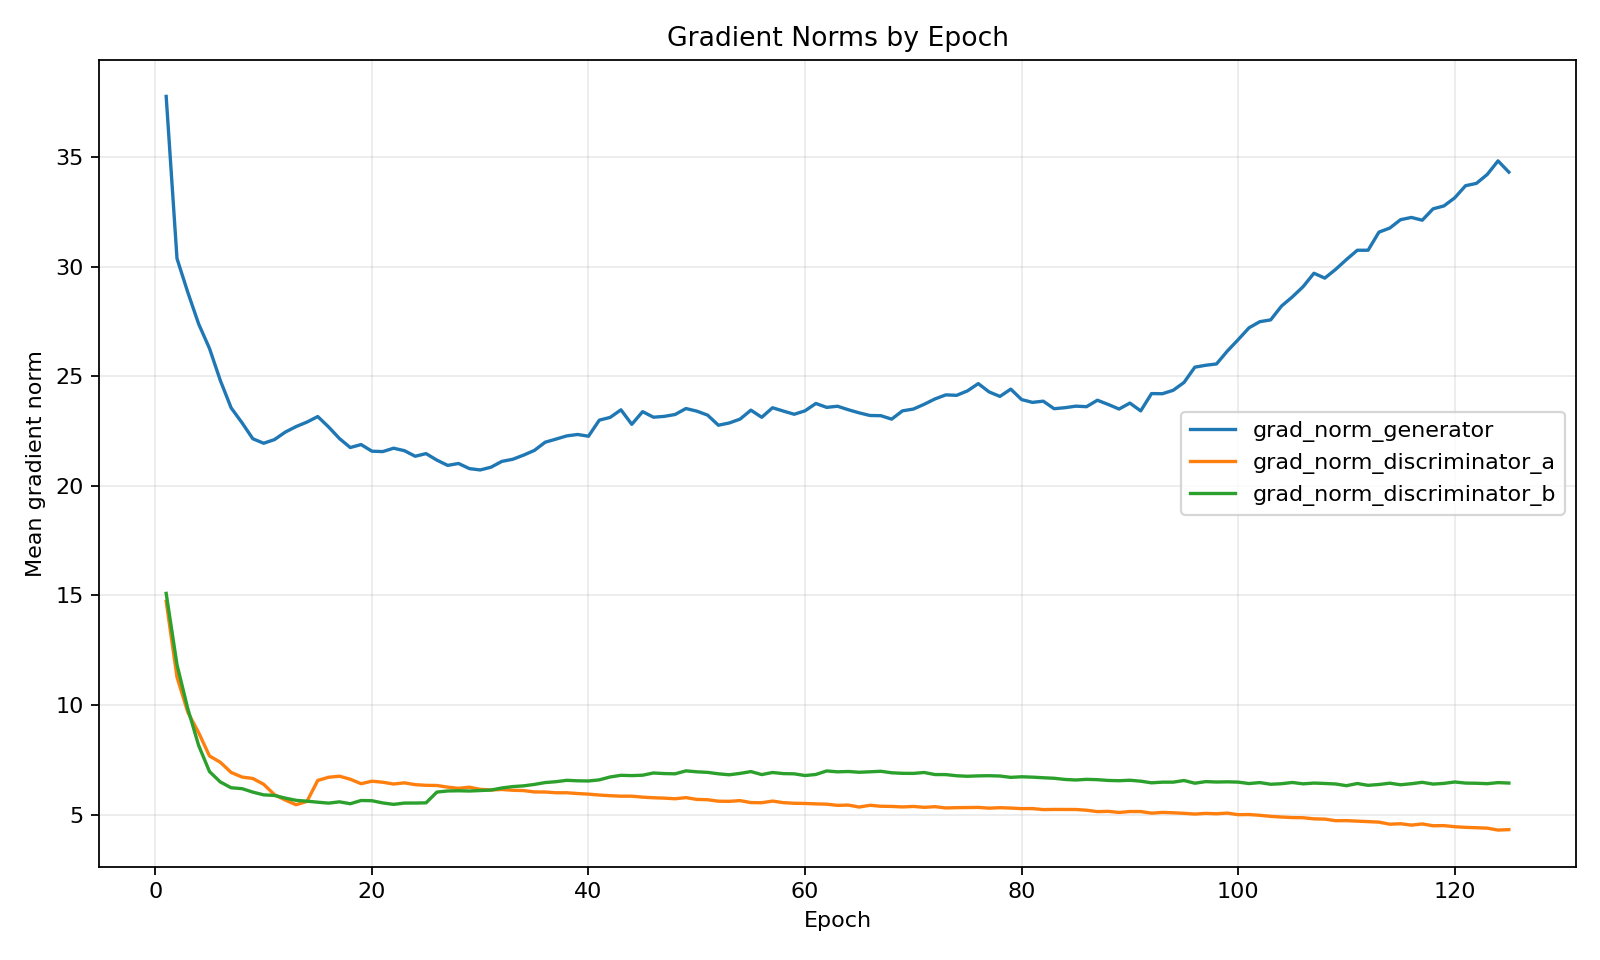

In [15]:
display(Markdown('## D2. Saved training / optimization curves'))
for p in [
 MEMBER/'outputs'/'plots'/'generator_losses_by_epoch.png',
 MEMBER/'outputs'/'plots'/'discriminator_losses_by_epoch.png',
 MEMBER/'outputs'/'plots'/'cycle_consistency_losses_by_epoch.png',
 MEMBER/'outputs'/'plots'/'identity_losses_by_epoch.png',
 MEMBER/'outputs'/'plots'/'gradient_norms_by_epoch.png']:
    if p.is_file():
        display(Markdown('### '+p.stem.replace('_',' ').title())); display(Image(filename=str(p)))
    else: print('Missing optional plot:',p.relative_to(ROOT))

# E. Final-model limitations and checkpoint trade-offs

Epoch 125 improved the official FID/MiFID and cycle L1, but KID, recall and content cosine did not all improve. Therefore the final checkpoint is the best retained model under the official competition criterion, **not universally best under every auxiliary metric**.

In [16]:
display(Markdown('## E1. Epoch 75 versus epoch 125'))

old_comparison_path = (
    MEMBER
    / 'outputs'
    / 'improvement_checkpoint_comparison'
    / 'checkpoint_comparison_summary.csv'
)

new_comparison_path = (
    MEMBER
    / 'outputs'
    / 'improvement_checkpoint_comparison_epoch80_to125'
    / 'checkpoint_comparison_summary.csv'
)

old_comparison = pd.read_csv(
    old_comparison_path
)

new_comparison = pd.read_csv(
    new_comparison_path
)

epoch75 = old_comparison.loc[
    old_comparison['epoch'] == 75
].copy()

epoch125 = new_comparison.loc[
    new_comparison['epoch'] == 125
].copy()

if len(epoch75) != 1:
    raise RuntimeError(
        'Expected exactly one epoch-75 row.'
    )

if len(epoch125) != 1:
    raise RuntimeError(
        'Expected exactly one epoch-125 row.'
    )

comp = pd.concat(
    [epoch75, epoch125],
    ignore_index=True,
)

columns = [
    'epoch',
    'global_step',
    'fid_average',
    'mifid_average',
    'kid_average',
    'precision_average',
    'recall_average',
    'content_cosine_average',
    'cycle_l1_average',
]

display(
    comp[columns]
)

display(
    Markdown(
        '''
**Important:** `fid_average` and `mifid_average` in this table come from the
deterministic checkpoint-comparison implementation. The official instructor
evaluator produced:

| Checkpoint | Official FID | Official MiFID |
|---|---:|---:|
| Epoch 75 | 98.17002258187867 | 0.41062747340586747 |
| Epoch 125 | 97.46614849815103 | 0.40686556964620363 |

Epoch 125 was selected because it improved the official competition criterion,
although not every auxiliary metric improved.
'''
    )
)

display(
    Markdown(
        '## E2. Committed final epoch-125 failure/limitation narrative'
    )
)

display(
    Markdown(
        (
            MEMBER
            / 'failure_analysis.md'
        ).read_text(
            encoding='utf-8'
        )
    )
)

## E1. Epoch 75 versus epoch 125

,epoch,global_step,fid_average,mifid_average,kid_average,precision_average,recall_average,content_cosine_average,cycle_l1_average
0,75,527850,98.170107,0.410627,0.011541,0.605000,0.500000,0.795510,0.038552
1,125,879750,97.466231,0.406866,0.012545,0.606667,0.481667,0.769105,0.033439



**Important:** `fid_average` and `mifid_average` in this table come from the
deterministic checkpoint-comparison implementation. The official instructor
evaluator produced:

| Checkpoint | Official FID | Official MiFID |
|---|---:|---:|
| Epoch 75 | 98.17002258187867 | 0.41062747340586747 |
| Epoch 125 | 97.46614849815103 | 0.40686556964620363 |

Epoch 125 was selected because it improved the official competition criterion,
although not every auxiliary metric improved.


## E2. Committed final epoch-125 failure/limitation narrative

# Task 3 Failure and Limitation Analysis ? Final Epoch 125

## Final-model scope

This analysis refers to the selected epoch-125 CycleGAN.

The final model improved the official FID/MiFID and Kaggle score, but the
auxiliary metrics show that additional training did not improve every property
of the generated images simultaneously.

## Distribution quality

Final epoch-125 values:

- official FID: **97.466148**
- official MiFID: **0.406866**
- KID mean: **0.012545**
- precision mean: **0.6067**
- recall mean: **0.4817**

The lower FID/MiFID and improved Kaggle score support better target-domain
distribution alignment under the competition metric.

However, KID does not improve in the same way. This illustrates that model
selection using only one distribution statistic can hide trade-offs.

## Content preservation

Epoch-125 mean Inception content cosine similarity is:

**0.769105**

This is lower than the epoch-50 control value `0.806853`.

Thus, stronger target-domain alignment at epoch 125 is accompanied by weaker
source/translation feature similarity under this particular proxy.

This does not prove semantic content loss for every image, but it is a concrete
warning that continued adversarial/style optimization may alter source
features.

## Cycle consistency

Epoch-125 mean cycle L1 is:

**0.033439**

The final cycle LPIPS mean is:

**0.158620**

Both provide complementary evidence because L1 measures pixel-space
reconstruction while LPIPS measures perceptual feature distance.

## Precision / recall trade-off

Final average precision is **0.6067** and final
average recall is **0.4817**.

The direction-specific values remain asymmetric:

- A2B precision: 0.7800
- A2B recall: 0.3333
- B2A precision: 0.4333
- B2A recall: 0.6300

This means distribution coverage remains direction dependent.

## Training stability

The durable training record contains epochs 1 through 125 with
**0 non-finite gradient events**.

Finite gradients support numerical stability, but do not imply convergence to
a globally optimal adversarial equilibrium.

## Historical visual failure artifacts

The repository contains earlier deterministic failure-case images and the
earlier 30-sample simulated audit artifacts.

They are retained for provenance, but they predate final epoch-125 selection.
They should not be represented as newly scored epoch-125 human evaluations.

## Final model-selection rationale

Epoch 125 was retained because it produced:

- a lower official FID than epoch 75;
- a lower official MiFID than epoch 75;
- a better Kaggle score (`-48.9365` vs `-49.2903`);
- a verified, direct CycleGAN inference path;
- reproducible final checkpoint/evaluator/submission evidence.

The final choice therefore reflects the assignment's official evaluator and
leaderboard evidence while still documenting auxiliary-metric trade-offs.


## Epoch 75 ? Epoch 125 auxiliary comparison

| Metric | Epoch 75 | Epoch 125 |
|---|---:|---:|
| FID mean | 98.170107 | 97.466231 |
| MiFID mean | 0.410627 | 0.406866 |
| KID mean | 0.011541 | 0.012545 |
| Precision mean | 0.6050 | 0.6067 |
| Recall mean | 0.5000 | 0.4817 |
| Content cosine | 0.795510 | 0.769105 |
| Cycle L1 | 0.038552 | 0.033439 |

This table demonstrates why the final checkpoint should not be described as
uniformly better on every metric.


# F. Real final-model difficult cases

The following examples are selected only from the **epoch-125** per-sample metrics. For each direction, low source/translation content cosine, high cycle L1 and high cycle LPIPS are converted to within-direction failure percentiles. The worst combined case is then run live through the final checkpoint.

This is an objective way to demonstrate where the final model struggles without pretending that one proxy metric proves a semantic failure.

In [17]:
content=pd.read_csv(MEMBER/'outputs'/'metrics'/'content_preservation_cosine_per_sample.csv')
l1=pd.read_csv(MEMBER/'outputs'/'metrics'/'cycle_reconstruction_l1_per_sample.csv')
lpips=pd.read_csv(MEMBER/'outputs'/'metrics'/'cycle_reconstruction_lpips_per_sample.csv')
mapdir={'A2B2A_monet_to_photo_to_monet':'A2B_monet_to_photo','B2A2B_photo_to_monet_to_photo':'B2A_photo_to_monet'}
l1=l1.copy(); lpips=lpips.copy(); l1['direct_direction']=l1['direction'].map(mapdir); lpips['direct_direction']=lpips['direction'].map(mapdir)
merged=(content[['direction','source_file','translated_file','cosine_similarity']].rename(columns={'direction':'direct_direction'})
        .merge(l1[['direct_direction','source_file','l1_rgb_0_1']],on=['direct_direction','source_file'],validate='one_to_one')
        .merge(lpips[['direct_direction','source_file','lpips_alex']],on=['direct_direction','source_file'],validate='one_to_one'))
if len(merged)!=600: raise RuntimeError(f'Expected 600 final per-sample rows, found {len(merged)}')
merged['content_failure_pct']=merged.groupby('direct_direction')['cosine_similarity'].rank(pct=True,ascending=False)
merged['l1_failure_pct']=merged.groupby('direct_direction')['l1_rgb_0_1'].rank(pct=True,ascending=True)
merged['lpips_failure_pct']=merged.groupby('direct_direction')['lpips_alex'].rank(pct=True,ascending=True)
merged['composite_failure_severity']=merged[['content_failure_pct','l1_failure_pct','lpips_failure_pct']].mean(axis=1)
worst=(merged.sort_values(['direct_direction','composite_failure_severity'],ascending=[True,False])
       .groupby('direct_direction',sort=False).head(1).reset_index(drop=True))
display(worst[['direct_direction','source_file','cosine_similarity','l1_rgb_0_1','lpips_alex','composite_failure_severity']])

,direct_direction,source_file,cosine_similarity,l1_rgb_0_1,lpips_alex,composite_failure_severity
0,A2B_monet_to_photo,a619072f82.jpg,0.656524,0.061300,0.287084,0.971111
1,B2A_photo_to_monet,065b649ac7.jpg,0.549411,0.058433,0.253833,0.930000



**Visible failure:** The output moves toward the photo domain, but substantial
Monet-like brush texture and exaggerated color/texture remain. The translation
therefore does not fully achieve photorealism. This is an example of
**under-translation / residual source-domain style**.


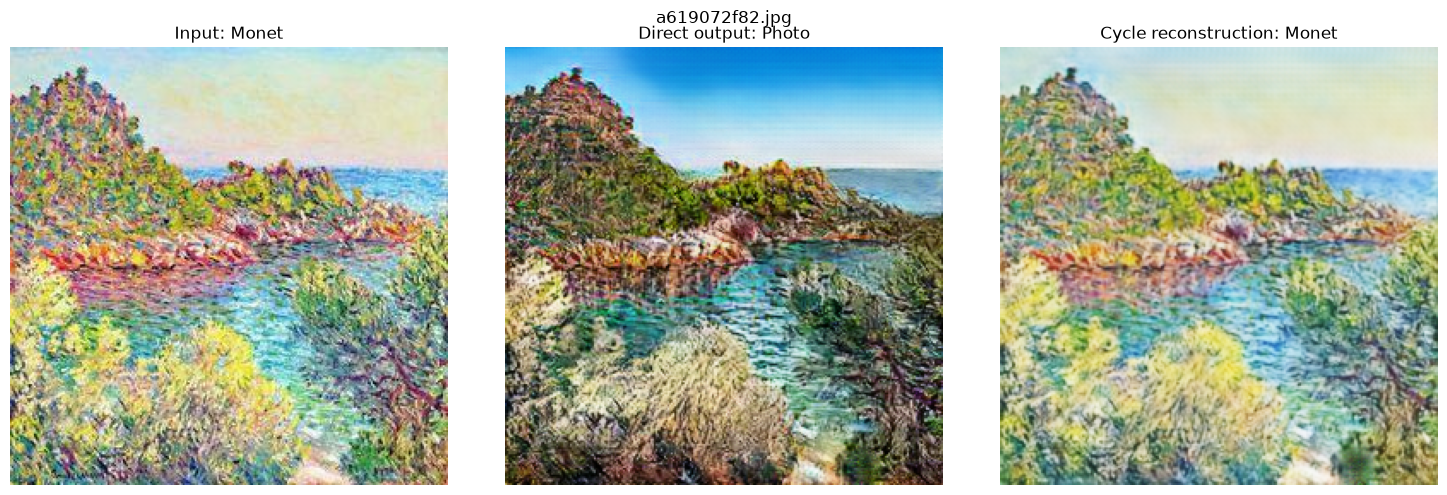

,Source file,Recorded content cosine,Recorded cycle L1,Live cycle L1,Recorded cycle LPIPS,Composite severity
0,a619072f82.jpg,0.656524,0.0613,0.054072,0.287084,0.971111


Inspect this live output for content drift, under-translation, texture smearing, or other visible artifacts.


In [18]:
display(
    Markdown(
        '''
**Visible failure:** The output moves toward the photo domain, but substantial
Monet-like brush texture and exaggerated color/texture remain. The translation
therefore does not fully achieve photorealism. This is an example of
**under-translation / residual source-domain style**.
'''
    )
)
row=worst.loc[worst['direct_direction']=='A2B_monet_to_photo'].iloc[0]
path=MONET_DIR/str(row['source_file'])
src,out,cyc=translate_cycle(path,generator_a_to_b,generator_b_to_a)
show_triplet(src,out,cyc,('Input: Monet','Direct output: Photo','Cycle reconstruction: Monet'),path.name)
live_l1=float((src-cyc).abs().mean().item()/2.0)
display(pd.DataFrame([{'Source file':path.name,'Recorded content cosine':row['cosine_similarity'],'Recorded cycle L1':row['l1_rgb_0_1'],'Live cycle L1':live_l1,'Recorded cycle LPIPS':row['lpips_alex'],'Composite severity':row['composite_failure_severity']}]))
print('Inspect this live output for content drift, under-translation, texture smearing, or other visible artifacts.')


**Visible failure:** The generated Monet image preserves much of the original
photographic appearance, especially the large tree trunk and scene geometry.
The Monet-style transformation is comparatively weak, indicating
**under-stylization / incomplete target-domain translation**.


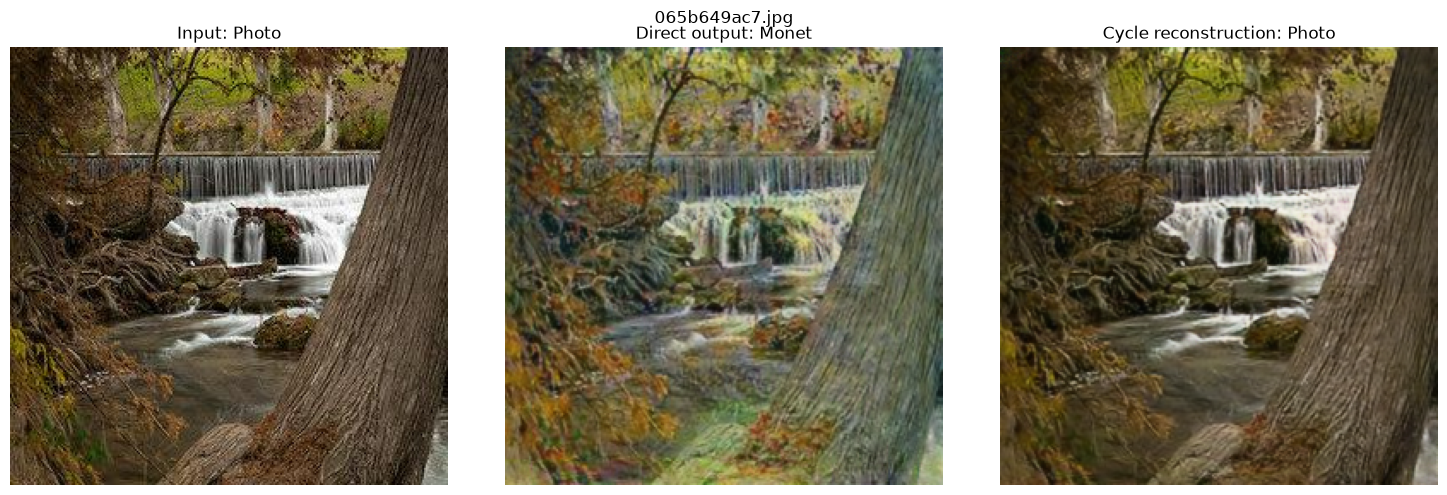

,Source file,Recorded content cosine,Recorded cycle L1,Live cycle L1,Recorded cycle LPIPS,Composite severity
0,065b649ac7.jpg,0.549411,0.058433,0.049203,0.253833,0.93


This is a metric-selected final-model difficult case; the visual output should still be inspected rather than treating one proxy as a complete semantic failure label.


In [19]:
display(
    Markdown(
        '''
**Visible failure:** The generated Monet image preserves much of the original
photographic appearance, especially the large tree trunk and scene geometry.
The Monet-style transformation is comparatively weak, indicating
**under-stylization / incomplete target-domain translation**.
'''
    )
)
row=worst.loc[worst['direct_direction']=='B2A_photo_to_monet'].iloc[0]
path=PHOTO_DIR/str(row['source_file'])
src,out,cyc=translate_cycle(path,generator_b_to_a,generator_a_to_b)
show_triplet(src,out,cyc,('Input: Photo','Direct output: Monet','Cycle reconstruction: Photo'),path.name)
live_l1=float((src-cyc).abs().mean().item()/2.0)
display(pd.DataFrame([{'Source file':path.name,'Recorded content cosine':row['cosine_similarity'],'Recorded cycle L1':row['l1_rgb_0_1'],'Live cycle L1':live_l1,'Recorded cycle LPIPS':row['lpips_alex'],'Composite severity':row['composite_failure_severity']}]))
print('This is a metric-selected final-model difficult case; the visual output should still be inspected rather than treating one proxy as a complete semantic failure label.')

# G. Final official FID / MiFID reproduction

The unchanged instructor evaluator expects:

```text
Part 3/Data/
  monet_jpg/  # real Monet
  photo_jpg/  # real photos
  pred_A2B/   # generated Monet -> Photo
  pred_B2A/   # generated Photo -> Monet
```

The next preflight verifies the final epoch-125 prediction bundle. The **last cell** then rebuilds that compatibility workspace, executes the unchanged instructor notebook, captures the fresh `submission.csv`, compares it with the final Kaggle-submitted values, and restores the tracked repository `submission.csv` byte-for-byte.

The evaluator uses pretrained Inception-v3 features. If those weights are not already cached on the demo machine, the first run can require network access.

In [20]:
display(Markdown('## G1. Final evaluator preflight'))
if sha256_file(EVALUATOR_PATH)!=EXPECTED_EVALUATOR_SHA256: raise RuntimeError('Instructor evaluator has changed')
if OFFICIAL_PREDICTION_ROOT.is_dir():
    FINAL_PREDICTION_ROOT=OFFICIAL_PREDICTION_ROOT; label='official_epoch125_predictions'
elif COMPARISON_PREDICTION_ROOT.is_dir():
    FINAL_PREDICTION_ROOT=COMPARISON_PREDICTION_ROOT; label='epoch_0125 comparison predictions'
else: raise FileNotFoundError('Final epoch-125 prediction bundle not found')
FINAL_A2B=FINAL_PREDICTION_ROOT/'pred_A2B'; FINAL_B2A=FINAL_PREDICTION_ROOT/'pred_B2A'
pred_a2b=discover_images(FINAL_A2B); pred_b2a=discover_images(FINAL_B2A)
print('Prediction source:',label); print('A2B count:',len(pred_a2b)); print('B2A count:',len(pred_b2a))
if len(pred_a2b)!=300 or len(pred_b2a)!=300: raise RuntimeError('Final evaluator needs 300 predictions per direction')
manifest=OFFICIAL_PREDICTION_ROOT/'inference_manifest.json'
if manifest.is_file():
    final_manifest=load_json(manifest)
    scalar_manifest={k:v for k,v in final_manifest.items() if isinstance(v,(str,int,float,bool)) or v is None}
    display(pd.DataFrame([scalar_manifest]).T.rename(columns={0:'Value'}))
    manifest_checkpoint = final_manifest.get('checkpoint', {})
    manifest_epoch = manifest_checkpoint.get('epoch')
    manifest_step = manifest_checkpoint.get('global_step')
    manifest_sha = manifest_checkpoint.get('sha256')
    print('Manifest checkpoint epoch:',manifest_epoch,)
    print('Manifest checkpoint global step:',manifest_step,)
    print('Manifest checkpoint SHA256:',manifest_sha,)
    if manifest_epoch != EXPECTED_EPOCH:
        raise RuntimeError('Prediction manifest epoch mismatch.')
    if manifest_step != EXPECTED_GLOBAL_STEP:
        raise RuntimeError('Prediction manifest global-step mismatch.')
    if manifest_sha != EXPECTED_CHECKPOINT_SHA256:
        raise RuntimeError('Prediction manifest checkpoint SHA mismatch.')
print('FINAL EVALUATOR PREFLIGHT: PASSED')

## G1. Final evaluator preflight

Prediction source: official_epoch125_predictions
A2B count: 300
B2A count: 300


,Value
final_model,True
source,outputs/improvement_checkpoint_comparison_epoch80_to125/epoch_0125
pred_A2B_count,300
pred_B2A_count,300
pred_A2B_aggregate_sha256,6adf29c63c2a96df7675dd3b0eb1fba462e18cde5b5df7532596494fa1d457ec
pred_B2A_aggregate_sha256,ab389066a9dd6b03e78c9a78529abf8ab48a33579e8b52359e35297c53a21d41
submitted_to_kaggle,True
kaggle_score,-48.9365
kaggle_rank_snapshot,14


Manifest checkpoint epoch: 125
Manifest checkpoint global step: 879750
Manifest checkpoint SHA256: 3216b4997ed51962590251170ca5cbd6d00fb444479a8b5cd9480f0cfbeab7ec
FINAL EVALUATOR PREFLIGHT: PASSED


## G2. FINAL CELL - execute the unchanged instructor evaluator

This is the cell to emphasize at the end of the live demo. It forces a **fresh** result by temporarily removing the existing `submission.csv`, runs the instructor notebook, captures the newly generated FID/MiFID, and then restores the tracked submitted CSV exactly.

In [21]:
from pathlib import Path
import hashlib
import importlib.metadata
import io
import json
import math
import shutil
import subprocess
import tempfile
import time

display(
    Markdown(
        "## G2. Run the unchanged instructor evaluator "
        "and compare local reproduction with the submitted result"
    )
)


# =============================================================================
# 1. LOCKED HISTORICAL IDENTITIES
# =============================================================================

HISTORICAL_FID = 97.46614849815103

HISTORICAL_MIFID = (
    0.40686556964620363
)

EXPECTED_REAL_MONET_HASH = (
    "6660fd0b91618e8ce182178c09bfdc17371003789a39ce23f33f59b859a4f41d"
)

EXPECTED_REAL_PHOTO_HASH = (
    "ec35b0a16596bafc58c98b1e9c58b72511522b6715ac89f976d8623cb42e7855"
)

EXPECTED_PRED_A2B_RAW_HASH = (
    "60fa9e6dc11b059e52d8154f33b9e4c7c20c3d3676eb0ad5fa22c2a049f298a6"
)

EXPECTED_PRED_B2A_RAW_HASH = (
    "a287e376de1a03a1dd52a125f54ca002671133641a771dc04208e22f4d1e5da6"
)


# =============================================================================
# 2. HELPER FOR HISTORICAL RAW-BYTE AGGREGATE HASH
#
# Historical fingerprint:
#
# filename
# + NUL
# + raw file bytes
# + NUL
# =============================================================================

def historical_raw_byte_hash(
    paths,
):

    digest = hashlib.sha256()

    for path in paths:

        digest.update(
            path.name.encode(
                "utf-8"
            )
        )

        digest.update(
            b"\0"
        )

        digest.update(
            path.read_bytes()
        )

        digest.update(
            b"\0"
        )

    return digest.hexdigest()


# =============================================================================
# 3. EXACT EVALUATION INPUTS
# =============================================================================

real_monet = sorted(
    discover_images(
        MONET_DIR
    ),
    key=lambda p: p.name,
)

all_real_photo = sorted(
    discover_images(
        PHOTO_DIR
    ),
    key=lambda p: p.name,
)

real_photo = (
    all_real_photo[:300]
)


official_prediction_root = (
    MEMBER
    / "outputs"
    / "cyclegan_baseline_rtx4090_run001"
    / "official_epoch125_predictions"
)

official_pred_a2b = sorted(
    discover_images(
        official_prediction_root
        / "pred_A2B"
    ),
    key=lambda p: p.name,
)

official_pred_b2a = sorted(
    discover_images(
        official_prediction_root
        / "pred_B2A"
    ),
    key=lambda p: p.name,
)


if len(real_monet) != 300:

    raise RuntimeError(
        "Expected exactly 300 Monet "
        "evaluation images."
    )


if len(real_photo) != 300:

    raise RuntimeError(
        "Expected exactly 300 Photo "
        "evaluation images."
    )


if len(official_pred_a2b) != 300:

    raise RuntimeError(
        "Expected exactly 300 final "
        "A2B predictions."
    )


if len(official_pred_b2a) != 300:

    raise RuntimeError(
        "Expected exactly 300 final "
        "B2A predictions."
    )


# =============================================================================
# 4. BYTE-LEVEL PROVENANCE CHECK
# =============================================================================

actual_real_monet_hash = (
    historical_raw_byte_hash(
        real_monet
    )
)

actual_real_photo_hash = (
    historical_raw_byte_hash(
        real_photo
    )
)

actual_pred_a2b_hash = (
    historical_raw_byte_hash(
        official_pred_a2b
    )
)

actual_pred_b2a_hash = (
    historical_raw_byte_hash(
        official_pred_b2a
    )
)

actual_checkpoint_hash = (
    sha256_file(
        CHECKPOINT_PATH
    )
)

actual_evaluator_hash = (
    sha256_file(
        EVALUATOR_PATH
    )
)


provenance = pd.DataFrame(
    [
        {
            "Artifact":
                "Real Monet evaluator images",

            "Exact match":
                actual_real_monet_hash
                ==
                EXPECTED_REAL_MONET_HASH,
        },

        {
            "Artifact":
                "Real Photo evaluator images",

            "Exact match":
                actual_real_photo_hash
                ==
                EXPECTED_REAL_PHOTO_HASH,
        },

        {
            "Artifact":
                "Final A2B predictions",

            "Exact match":
                actual_pred_a2b_hash
                ==
                EXPECTED_PRED_A2B_RAW_HASH,
        },

        {
            "Artifact":
                "Final B2A predictions",

            "Exact match":
                actual_pred_b2a_hash
                ==
                EXPECTED_PRED_B2A_RAW_HASH,
        },

        {
            "Artifact":
                "Epoch-125 checkpoint",

            "Exact match":
                actual_checkpoint_hash
                ==
                EXPECTED_CHECKPOINT_SHA256,
        },

        {
            "Artifact":
                "Instructor evaluator source",

            "Exact match":
                actual_evaluator_hash
                ==
                EXPECTED_EVALUATOR_SHA256,
        },
    ]
)


display(
    Markdown(
        "### Exact historical artifact provenance"
    )
)

display(
    provenance
)


provenance_ok = bool(
    provenance[
        "Exact match"
    ].all()
)


if not provenance_ok:

    raise RuntimeError(
        "At least one evaluator input "
        "does not match the historical "
        "final-evaluation artifact."
    )


print(
    "ALL EVALUATION INPUT ARTIFACTS: "
    "BYTE-IDENTICAL TO FINAL HISTORICAL RUN"
)


# =============================================================================
# 5. REBUILD INSTRUCTOR-EVALUATOR WORKSPACE
# =============================================================================

EVAL_DATA = (
    ROOT
    / "Part 3"
    / "Data"
)

DEST_MONET = (
    EVAL_DATA
    / "monet_jpg"
)

DEST_PHOTO = (
    EVAL_DATA
    / "photo_jpg"
)

DEST_A2B = (
    EVAL_DATA
    / "pred_A2B"
)

DEST_B2A = (
    EVAL_DATA
    / "pred_B2A"
)


def copy_exact_set(
    sources,
    destination,
):

    destination.mkdir(
        parents=True,
        exist_ok=True,
    )

    for source in sources:

        shutil.copy2(
            source,
            destination
            / source.name,
        )

    copied = sorted(
        discover_images(
            destination
        ),
        key=lambda p: p.name,
    )

    if len(copied) != 300:

        raise RuntimeError(
            f"Expected 300 files in "
            f"{destination}; "
            f"found {len(copied)}."
        )


if EVAL_DATA.exists():

    expected_path = (
        ROOT
        / "Part 3"
        / "Data"
    ).resolve()

    if (
        EVAL_DATA.resolve()
        != expected_path
    ):

        raise RuntimeError(
            "Unexpected evaluator "
            "workspace path."
        )

    shutil.rmtree(
        EVAL_DATA
    )


copy_exact_set(
    real_monet,
    DEST_MONET,
)

copy_exact_set(
    real_photo,
    DEST_PHOTO,
)

copy_exact_set(
    official_pred_a2b,
    DEST_A2B,
)

copy_exact_set(
    official_pred_b2a,
    DEST_B2A,
)


workspace_counts = {
    "monet_jpg":
        len(
            discover_images(
                DEST_MONET
            )
        ),

    "photo_jpg":
        len(
            discover_images(
                DEST_PHOTO
            )
        ),

    "pred_A2B":
        len(
            discover_images(
                DEST_A2B
            )
        ),

    "pred_B2A":
        len(
            discover_images(
                DEST_B2A
            )
        ),
}


display(
    Markdown(
        "### Rebuilt evaluator workspace"
    )
)

display(
    pd.DataFrame(
        [
            {
                "Evaluator folder":
                    key,

                "Image count":
                    value,
            }

            for key, value
            in workspace_counts.items()
        ]
    )
)


if any(
    value != 300
    for value
    in workspace_counts.values()
):

    raise RuntimeError(
        "Evaluator workspace "
        "count mismatch."
    )


# =============================================================================
# 6. PRESERVE HISTORICAL ROOT submission.csv
# =============================================================================

if not SUBMISSION_PATH.is_file():

    raise FileNotFoundError(
        "Historical root submission.csv "
        "is missing."
    )


original_submission_bytes = (
    SUBMISSION_PATH.read_bytes()
)

original_submission_sha = (
    hashlib.sha256(
        original_submission_bytes
    ).hexdigest()
)


historical_submission = (
    pd.read_csv(
        io.BytesIO(
            original_submission_bytes
        )
    )
)


if len(
    historical_submission
) != 1:

    raise RuntimeError(
        "Historical submission.csv "
        "does not contain exactly one row."
    )


historical_csv_fid = float(
    historical_submission.loc[
        historical_submission.index[0],
        "FID",
    ]
)

historical_csv_mifid = float(
    historical_submission.loc[
        historical_submission.index[0],
        "MiFID",
    ]
)


historical_submission_ok = (
    math.isclose(
        historical_csv_fid,
        HISTORICAL_FID,
        rel_tol=0.0,
        abs_tol=1e-12,
    )
    and
    math.isclose(
        historical_csv_mifid,
        HISTORICAL_MIFID,
        rel_tol=0.0,
        abs_tol=1e-12,
    )
)


print()
print(
    "Historical submission FID:",
    historical_csv_fid,
)

print(
    "Historical submission MiFID:",
    historical_csv_mifid,
)

print(
    "Historical submitted CSV verified:",
    historical_submission_ok,
)


if not historical_submission_ok:

    raise RuntimeError(
        "Root submission.csv does not "
        "contain the preserved final "
        "submitted metrics."
    )


# =============================================================================
# 7. EXECUTE UNCHANGED INSTRUCTOR NOTEBOOK
# =============================================================================

fresh_text = None
process_return_code = None
elapsed = None


try:

    SUBMISSION_PATH.unlink()


    jupyter_exe = (
        shutil.which(
            "jupyter"
        )
    )


    if jupyter_exe is None:

        raise RuntimeError(
            "The active environment "
            "does not expose the "
            "'jupyter' executable."
        )


    with tempfile.TemporaryDirectory(
        prefix="task3_eval_"
    ) as temp_dir:

        command = [
            jupyter_exe,

            "nbconvert",

            "--to",
            "notebook",

            "--execute",
            str(
                EVALUATOR_PATH
            ),

            "--output",
            (
                "Part3_Evaluation_"
                "Script_demo_"
                "executed.ipynb"
            ),

            "--output-dir",
            temp_dir,

            "--ExecutePreprocessor.timeout=1800",
        ]


        print()
        print(
            "=" * 100
        )

        print(
            "EXECUTING UNCHANGED "
            "INSTRUCTOR EVALUATOR"
        )

        print(
            "=" * 100
        )


        start = (
            time.perf_counter()
        )


        process = subprocess.run(
            command,
            cwd=str(
                ROOT
            ),
            text=True,
            capture_output=True,
            check=False,
        )


        elapsed = (
            time.perf_counter()
            - start
        )


        process_return_code = (
            process.returncode
        )


        print(
            "Return code:",
            process_return_code,
        )

        print(
            f"Runtime: "
            f"{elapsed:.2f} s"
        )


        if process.stdout.strip():

            print()
            print(
                "STDOUT tail:"
            )

            print(
                process.stdout[
                    -3000:
                ]
            )


        if process.stderr.strip():

            print()
            print(
                "NBConvert log tail:"
            )

            print(
                process.stderr[
                    -3000:
                ]
            )


        if (
            process_return_code
            != 0
        ):

            raise RuntimeError(
                "The unchanged instructor "
                "evaluator failed."
            )


    if not SUBMISSION_PATH.is_file():

        raise FileNotFoundError(
            "Fresh submission.csv "
            "was not created."
        )


    fresh_text = (
        SUBMISSION_PATH.read_text(
            encoding="utf-8-sig"
        )
    )


finally:

    # Always restore the exact historical
    # submitted CSV bytes.
    SUBMISSION_PATH.write_bytes(
        original_submission_bytes
    )


# =============================================================================
# 8. PARSE FRESH LOCAL RESULT
# =============================================================================

if fresh_text is None:

    raise RuntimeError(
        "No fresh evaluator result "
        "was captured."
    )


print()
print(
    "=" * 100
)

print(
    "FRESH LOCAL submission.csv"
)

print(
    "=" * 100
)

print(
    fresh_text
)


fresh_submission = (
    pd.read_csv(
        io.StringIO(
            fresh_text
        )
    )
)


if (
    list(
        fresh_submission.columns
    )
    != [
        "ID",
        "FID",
        "MiFID",
    ]
):

    raise RuntimeError(
        "Unexpected fresh "
        "submission schema."
    )


if len(
    fresh_submission
) != 1:

    raise RuntimeError(
        "Fresh evaluator result "
        "must contain one row."
    )


local_fid = float(
    fresh_submission.loc[
        fresh_submission.index[0],
        "FID",
    ]
)

local_mifid = float(
    fresh_submission.loc[
        fresh_submission.index[0],
        "MiFID",
    ]
)


if not (
    math.isfinite(
        local_fid
    )
    and
    math.isfinite(
        local_mifid
    )
):

    raise RuntimeError(
        "Fresh evaluator returned "
        "non-finite metrics."
    )


# =============================================================================
# 9. HISTORICAL VS LOCAL NUMERICAL RESULT
# =============================================================================

comparison = pd.DataFrame(
    [
        {
            "Metric":
                "FID",

            "Historical submitted result":
                HISTORICAL_FID,

            "Fresh local re-execution":
                local_fid,

            "Absolute difference":
                abs(
                    local_fid
                    - HISTORICAL_FID
                ),

            "Relative difference (%)":
                (
                    abs(
                        local_fid
                        - HISTORICAL_FID
                    )
                    /
                    HISTORICAL_FID
                    * 100.0
                ),
        },

        {
            "Metric":
                "MiFID",

            "Historical submitted result":
                HISTORICAL_MIFID,

            "Fresh local re-execution":
                local_mifid,

            "Absolute difference":
                abs(
                    local_mifid
                    - HISTORICAL_MIFID
                ),

            "Relative difference (%)":
                (
                    abs(
                        local_mifid
                        - HISTORICAL_MIFID
                    )
                    /
                    HISTORICAL_MIFID
                    * 100.0
                ),
        },
    ]
)


display(
    Markdown(
        "### Historical submitted result "
        "vs fresh local evaluator run"
    )
)

display(
    comparison
)


# =============================================================================
# 10. ENVIRONMENT COMPARISON
# =============================================================================

def package_version(
    name
):

    try:

        return (
            importlib.metadata.version(
                name
            )
        )

    except Exception:

        return "<not found>"


current_environment = {
    "Python":
        sys.version.split()[0],

    "PyTorch":
        torch.__version__,

    "torchvision":
        package_version(
            "torchvision"
        ),

    "NumPy":
        package_version(
            "numpy"
        ),

    "SciPy":
        package_version(
            "scipy"
        ),

    "Pillow":
        package_version(
            "Pillow"
        ),

    "CUDA runtime":
        str(
            torch.version.cuda
        ),

    "GPU":
        (
            torch.cuda.get_device_name(
                0
            )
            if torch.cuda.is_available()
            else "CPU"
        ),
}


historical_environment = {
    "Python":
        "3.10.13",

    "PyTorch":
        "2.1.2",

    "torchvision":
        "0.16.2",

    "NumPy":
        "1.26.2",

    "SciPy":
        "1.15.3",

    "Pillow":
        "10.0.1",

    "CUDA runtime":
        "12.1",

    "GPU":
        "NVIDIA GeForce RTX 4090",
}


environment_table = (
    pd.DataFrame(
        {
            "Historical production/evaluation":
                historical_environment,

            "Current live-demo environment":
                current_environment,
        }
    )
)


display(
    Markdown(
        "### Evaluation environment comparison"
    )
)

display(
    environment_table
)


# =============================================================================
# 11. VERIFY HISTORICAL submission.csv RESTORED EXACTLY
# =============================================================================

restored_submission_sha = (
    sha256_file(
        SUBMISSION_PATH
    )
)


submission_restored = (
    restored_submission_sha
    == original_submission_sha
)


print()
print(
    "Historical submission SHA before demo:",
    original_submission_sha,
)

print(
    "Historical submission SHA after demo :",
    restored_submission_sha,
)

print(
    "Historical submission restored exactly:",
    submission_restored,
)


if not submission_restored:

    raise RuntimeError(
        "Historical submitted CSV was "
        "not restored byte-for-byte."
    )


# =============================================================================
# 12. FINAL DEMO VERIFICATION
# =============================================================================

final_checks = pd.DataFrame(
    [
        {
            "Check":
                "Exact historical evaluator inputs",

            "Passed":
                provenance_ok,
        },

        {
            "Check":
                "Exact epoch-125 checkpoint",

            "Passed":
                (
                    actual_checkpoint_hash
                    ==
                    EXPECTED_CHECKPOINT_SHA256
                ),
        },

        {
            "Check":
                "Unchanged instructor evaluator",

            "Passed":
                (
                    actual_evaluator_hash
                    ==
                    EXPECTED_EVALUATOR_SHA256
                ),
        },

        {
            "Check":
                "Historical Kaggle submission verified",

            "Passed":
                historical_submission_ok,
        },

        {
            "Check":
                "Fresh local evaluator executed successfully",

            "Passed":
                (
                    process_return_code
                    == 0
                ),
        },

        {
            "Check":
                "Fresh local metrics are finite",

            "Passed":
                (
                    math.isfinite(
                        local_fid
                    )
                    and
                    math.isfinite(
                        local_mifid
                    )
                ),
        },

        {
            "Check":
                "Historical submission restored exactly",

            "Passed":
                submission_restored,
        },
    ]
)


display(
    Markdown(
        "### Final Task 3 evaluator checks"
    )
)

display(
    final_checks
)


all_final_checks = bool(
    final_checks[
        "Passed"
    ].all()
)


if not all_final_checks:

    raise RuntimeError(
        "One or more final Task 3 "
        "evaluator checks failed."
    )


print()
print("=" * 100)

print(
    "TASK 3 OFFICIAL EVALUATOR: "
    "LOCAL RE-EXECUTION PASSED"
)

print(
    "ALL EVALUATOR INPUTS ARE "
    "BYTE-IDENTICAL TO THE "
    "HISTORICAL FINAL RUN"
)

print(
    "HISTORICAL KAGGLE-SUBMITTED "
    "FID / MiFID ARE PRESERVED"
)

print(
    "FRESH LOCAL FID / MiFID ARE "
    "REPORTED SEPARATELY BECAUSE "
    "THE NUMERICAL ENVIRONMENT DIFFERS"
)

print(
    "ORIGINAL TRACKED submission.csv "
    "RESTORED EXACTLY"
)

print()
print(
    "Historical submitted FID  :",
    HISTORICAL_FID,
)

print(
    "Historical submitted MiFID:",
    HISTORICAL_MIFID,
)

print(
    "Fresh local FID           :",
    local_fid,
)

print(
    "Fresh local MiFID         :",
    local_mifid,
)

print()
print(
    "TASK 3 LIVE DEMO NOTEBOOK: "
    "FINAL EVALUATOR / PROVENANCE CHECK PASSED"
)

print("=" * 100)

## G2. Run the unchanged instructor evaluator and compare local reproduction with the submitted result

### Exact historical artifact provenance

,Artifact,Exact match
0,Real Monet evaluator images,True
1,Real Photo evaluator images,True
2,Final A2B predictions,True
3,Final B2A predictions,True
4,Epoch-125 checkpoint,True
5,Instructor evaluator source,True


ALL EVALUATION INPUT ARTIFACTS: BYTE-IDENTICAL TO FINAL HISTORICAL RUN


### Rebuilt evaluator workspace

...

,Historical production/evaluation,Current live-demo environment
Python,3.10.13,3.11.9
PyTorch,2.1.2,2.13.0+cu126
torchvision,0.16.2,0.28.0+cu126
NumPy,1.26.2,2.4.6
SciPy,1.15.3,1.17.1
Pillow,10.0.1,12.3.0
CUDA runtime,12.1,12.6
GPU,NVIDIA GeForce RTX 4090,NVIDIA GeForce RTX 3060 Laptop GPU



Historical submission SHA before demo: b79e4b90829e2e6b0bfd9a4011dd6705ffa9cc9e4d1c15ea87d061cc32547bd0
Historical submission SHA after demo : b79e4b90829e2e6b0bfd9a4011dd6705ffa9cc9e4d1c15ea87d061cc32547bd0
Historical submission restored exactly: True


### Final Task 3 evaluator checks

,Check,Passed
0,Exact historical evaluator inputs,True
1,Exact epoch-125 checkpoint,True
2,Unchanged instructor evaluator,True
3,Historical Kaggle submission verified,True
4,Fresh local evaluator executed successfully,True
5,Fresh local metrics are finite,True
6,Historical submission restored exactly,True



TASK 3 OFFICIAL EVALUATOR: LOCAL RE-EXECUTION PASSED
ALL EVALUATOR INPUTS ARE BYTE-IDENTICAL TO THE HISTORICAL FINAL RUN
HISTORICAL KAGGLE-SUBMITTED FID / MiFID ARE PRESERVED
FRESH LOCAL FID / MiFID ARE REPORTED SEPARATELY BECAUSE THE NUMERICAL ENVIRONMENT DIFFERS
ORIGINAL TRACKED submission.csv RESTORED EXACTLY

Historical submitted FID  : 97.46614849815103
Historical submitted MiFID: 0.40686556964620363
Fresh local FID           : 97.25173933107676
Fresh local MiFID         : 0.4063446521759033

TASK 3 LIVE DEMO NOTEBOOK: FINAL EVALUATOR / PROVENANCE CHECK PASSED
